# Phase 3 - Community Detection with ANGEL (overlap)

This notebook focuses on the overlap dimension: nodes may belong to multiple communities, enabling explicit analysis of boundary structure and bridge papers.

| | G_CitOnly | G_BC |
|---|---|---|
| **Type** | Undirected, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **ANGEL variant** | Threshold-based overlap | Threshold-based overlap (w/ weights) |

Scope of this phase:
- calibrate ANGEL parameters via sweep;
- build robust overlapping partitions via multi-run ensemble + medoid;
- quantify overlap rate changes and bridge paper topology after BC insertion;
- validate semantic consistency and merge significance via Gini permutation test.

In [1]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from cdlib import algorithms, NodeClustering, evaluation
from pathlib import Path

BASE_DIR = Path().resolve().parent.parent
GRAPH_DIR = BASE_DIR / "data" / "graph"
INTERNAL_PATH = GRAPH_DIR / "graph_internal_2020.gpickle"
COMBINED_PATH = GRAPH_DIR / "graph_combined_2020.gpickle"

OUTPUT_DIR = Path().resolve() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

THRESHOLD      = 0.45
MIN_COMM_SIZE  = 4
FATE_MIN_SIZE  = 20
TOP_N_COMMS    = 100
TOP_K          = 5
N_ENSEMBLE     = 30

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}


## Graph loading

In [2]:
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_CitOnly = load_graph(INTERNAL_PATH)
G_BC = load_graph(COMBINED_PATH)
G_CitOnly_undir = G_CitOnly.to_undirected()

for u, v, d in G_BC.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_BC.edges(data=True)]

print(f"G_CitOnly   {G_CitOnly.number_of_nodes():>7,} nodes   {G_CitOnly.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_BC   {G_BC.number_of_nodes():>7,} nodes   {G_BC.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_CitOnly    55,078 nodes    217,925 edges  (directed, unweighted)
G_BC    57,603 nodes    745,451 edges  (undirected, weighted)  median_w=0.338


## Shared utilities

In [3]:
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

In [4]:
fos_stats_path = OUTPUT_DIR / 'angel_FOS_stats.csv'
sdg_stats_path = OUTPUT_DIR / 'angel_SDG_stats.csv'

s_int  = compute_attr_stats(G_CitOnly)
s_comb = compute_attr_stats(G_BC)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv(fos_stats_path, index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv(sdg_stats_path, index=False)

print(f'{fos_stats_path.name}  {sdg_stats_path.name}  created')

angel_FOS_stats.csv  angel_SDG_stats.csv  created


In [5]:
# ──────────────────────────────────────────────
# Cache helpers
# ──────────────────────────────────────────────

def _safe_name(s):
    return re.sub(r'[^\w\-.]', '_', str(s))

def _cache_save(path, obj):
    with open(path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"    Cached: {path}")

def _cache_load(path):
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"    Loaded: {path}")
    return obj

## ANGEL - Parameter calibration

ANGEL (Rossetti et al., 2017) is highly sensitive to `threshold` and `min_community_size`.
Parameter screening is a methodological requirement.

The sweep evaluates all (threshold, min_size) pairs on both graphs, computing coverage,
overlap rate, modularity, conductance, and micro-community fraction. Results are cached.

In [6]:
ELBOW_CSV = OUTPUT_DIR / 'angel_elbow_sweep.csv'
THRESHOLDS_SWEEP = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
MIN_SIZES = list(range(4, 8))
N_WORKERS = 6
FORCE_RECOMPUTE_SWEEP = False

_WORKER_GRAPHS = {}

def _get_worker_graphs(int_path, comb_path):
    key = (int_path, comb_path)
    if key not in _WORKER_GRAPHS:
        import pickle
        with open(int_path, 'rb') as f:
            g_int = pickle.load(f).to_undirected()
        with open(comb_path, 'rb') as f:
            g_comb = pickle.load(f)
        _WORKER_GRAPHS[key] = (g_int, g_comb)
    return _WORKER_GRAPHS[key]


def _sweep_worker(args):
    int_path, comb_path, thr, min_size = args
    import time
    import numpy as np
    from collections import Counter
    from cdlib import algorithms, evaluation

    G_int, G_comb = _get_worker_graphs(int_path, comb_path)

    def _metrics(cl, G, all_nodes):
        mem = Counter(n for c in cl.communities for n in c)
        covered = set(mem)
        overlapping = {n for n, k in mem.items() if k > 1}
        sizes = [len(c) for c in cl.communities]
        avg_memberships = (np.mean([mem[n] for n in overlapping]) if overlapping else 0.0)
        mod_ol = evaluation.modularity_overlap(G, cl).score
        cond = evaluation.conductance(G, cl).score
        micro_frac = sum(1 for s in sizes if s < 5) / len(sizes) if sizes else 0.0
        return {
            'n_communities': len(cl.communities),
            'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
            'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
            'n_overlapping': len(overlapping),
            'avg_memberships': avg_memberships,
            'avg_comm_size': float(np.mean(sizes)) if sizes else 0.0,
            'median_comm_size': float(np.median(sizes)) if sizes else 0.0,
            'modularity_overlap': mod_ol,
            'conductance': cond,
            'micro_frac': micro_frac,
        }

    records = []
    for G, gname in [(G_int, 'G_CitOnly'), (G_comb, 'G_BC')]:
        t0 = time.time()
        cl = algorithms.angel(G, threshold=thr, min_community_size=min_size)
        m = _metrics(cl, G, set(G.nodes))
        records.append({
            'graph': gname, 'min_size': min_size, 'threshold': thr,
            **m, 'elapsed_s': round(time.time() - t0, 1),
        })
    return records


if not FORCE_RECOMPUTE_SWEEP and ELBOW_CSV.exists():
    df_sweep = pd.read_csv(ELBOW_CSV)
    print(f"Loaded sweep from {ELBOW_CSV}  ({len(df_sweep)} rows)")
else:
    int_path_str = str(INTERNAL_PATH)
    comb_path_str = str(COMBINED_PATH)
    args_list = [
        (int_path_str, comb_path_str, thr, ms)
        for thr in THRESHOLDS_SWEEP for ms in MIN_SIZES
    ]
    all_records = []
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        for result in pool.map(_sweep_worker, args_list):
            all_records.extend(result)
            done = len(all_records) // 2
            print(f"  {done}/{len(args_list)} configs done", end='\r')

    df_sweep = pd.DataFrame(all_records)
    df_sweep.to_csv(ELBOW_CSV, index=False)
    print(f"\nSweep saved to {ELBOW_CSV}  ({len(df_sweep)} rows)")

  44/44 configs done
Sweep saved to /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/angel_elbow_sweep.csv  (88 rows)


### Parameter selection

The sweep identifies the last stable point before fragmentation.
- Too low threshold → low overlap signal
- Too high threshold → many small/noisy communities

In [7]:
metrics_list = [
    ('n_communities',      'N communities',                        None),
    ('coverage',           'Coverage',                              None),
    ('overlap_rate',       'Overlap rate',                          None),
    ('avg_comm_size',      'Avg community size',                    None),
    ('modularity_overlap', 'Modularity (overlap)',                  'higher = better'),
    ('conductance',        'Conductance',                           'lower = better'),
    ('avg_memberships',    'Avg memberships\n(per overlap node)',  None),
    ('micro_frac',         'Micro-community\nfraction (<5 nodes)', None),
]

benefit_metrics = ['modularity_overlap', 'coverage', 'overlap_rate']
cost_metrics = ['conductance', 'micro_frac']
all_metrics = benefit_metrics + cost_metrics

# Robust pre-screen: worst-case aggregation across both graphs
robust = (
    df_sweep.pivot_table(
        index=['threshold', 'min_size'], columns='graph',
        values=all_metrics, aggfunc='mean'
    )
)
robust.columns = [f'{m}_{g}' for m, g in robust.columns]
robust = robust.reset_index()

for m in benefit_metrics:
    robust[f'wc_{m}'] = robust[[f'{m}_G_CitOnly', f'{m}_G_BC']].min(axis=1)
for m in cost_metrics:
    robust[f'wc_{m}'] = robust[[f'{m}_G_CitOnly', f'{m}_G_BC']].max(axis=1)

def _norm_max(x):
    lo, hi = x.min(), x.max()
    return pd.Series(1.0, index=x.index) if hi <= lo else (x - lo) / (hi - lo)

def _norm_min(x):
    lo, hi = x.min(), x.max()
    return pd.Series(1.0, index=x.index) if hi <= lo else (hi - x) / (hi - lo)

for m in benefit_metrics:
    robust[f'n_{m}'] = _norm_max(robust[f'wc_{m}'])
for m in cost_metrics:
    robust[f'n_{m}'] = _norm_min(robust[f'wc_{m}'])

norm_cols = [f'n_{m}' for m in all_metrics]
robust['dist_to_ideal'] = np.linalg.norm(robust[norm_cols].to_numpy() - 1.0, axis=1)
robust['maximin'] = robust[norm_cols].min(axis=1)
robust['utility'] = 1.0 - robust['dist_to_ideal'] / np.sqrt(len(norm_cols))

pre = robust.sort_values(['dist_to_ideal', 'maximin'], ascending=[True, False]).iloc[0]
pre_thr = float(pre['threshold'])
pre_ms = int(pre['min_size'])

print('Top-5 robust configurations:')
print(
    robust.sort_values(['dist_to_ideal', 'maximin'], ascending=[True, False])
          .head(5)[['threshold', 'min_size', 'dist_to_ideal', 'maximin', 'utility']]
          .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)
print(f"\nSelected: threshold={pre_thr:.2f}, min_size={pre_ms}")

# Override globals
THRESHOLD = pre_thr
MIN_COMM_SIZE = pre_ms

Top-5 robust configurations:
 threshold  min_size  dist_to_ideal  maximin  utility
    0.4500         4         0.9476   0.1092   0.5762
    0.4000         4         0.9524   0.0998   0.5741
    0.5500         5         0.9952   0.1976   0.5549
    0.5000         5         1.0019   0.1787   0.5520
    0.4500         5         1.0066   0.1184   0.5498

Selected: threshold=0.45, min_size=4


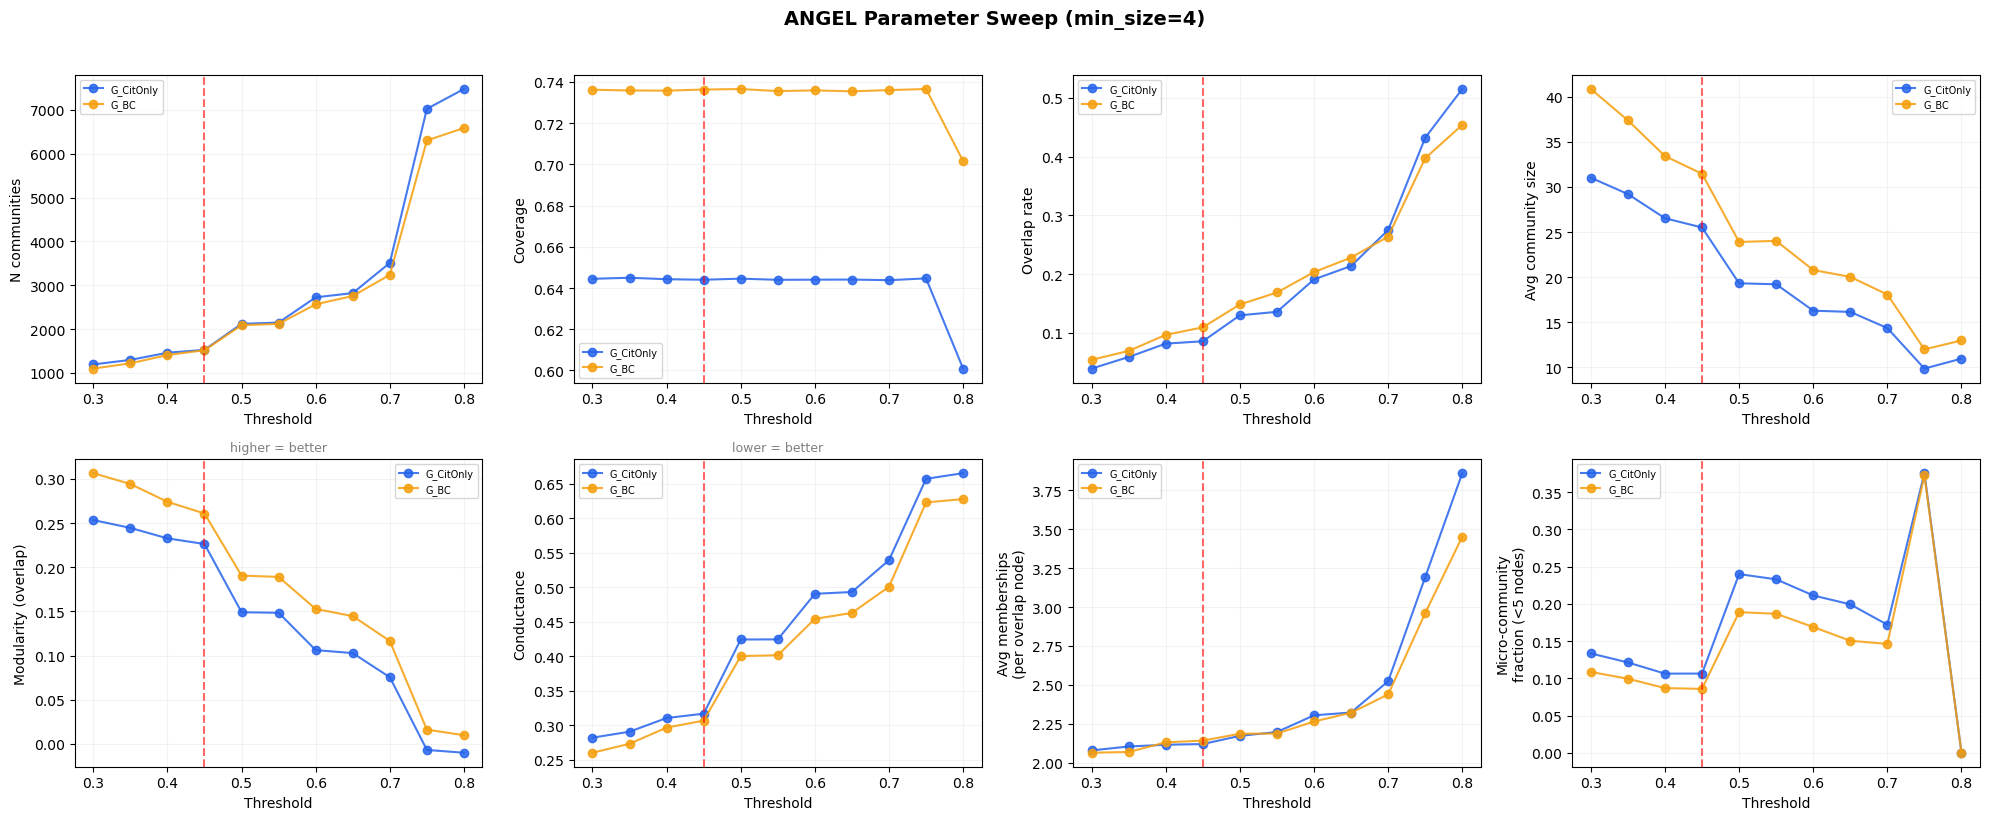

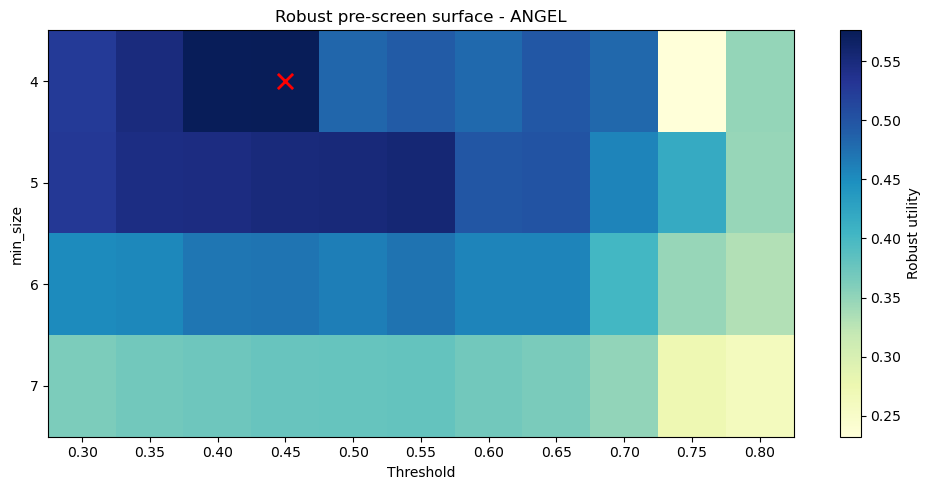

In [8]:
# Sweep visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'ANGEL Parameter Sweep (min_size={pre_ms})', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, ylabel, note) in zip(axes.ravel(), metrics_list):
    for gname, color in [('G_CitOnly', '#2563EB'), ('G_BC', '#F59E0B')]:
        sub = df_sweep[(df_sweep['graph'] == gname) & (df_sweep['min_size'] == pre_ms)]
        sub = sub.sort_values('threshold')
        ax.plot(sub['threshold'], sub[col], 'o-', color=color, label=gname, alpha=0.85)
    ax.axvline(pre_thr, ls='--', color='red', alpha=0.6)
    ax.set_xlabel('Threshold'); ax.set_ylabel(ylabel)
    if note:
        ax.set_title(note, fontsize=9, color='grey')
    ax.legend(fontsize=7); ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/angel_parameter_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

# Utility heatmap
piv = robust.pivot(index='min_size', columns='threshold', values='utility').sort_index()
plt.figure(figsize=(10, 5))
im = plt.imshow(piv.values, aspect='auto', cmap='YlGnBu')
plt.colorbar(im, label='Robust utility')
plt.xticks(range(len(piv.columns)), [f'{x:.2f}' for x in piv.columns])
plt.yticks(range(len(piv.index)), [str(int(x)) for x in piv.index])
plt.xlabel('Threshold'); plt.ylabel('min_size')
plt.title('Robust pre-screen surface - ANGEL')
px = list(piv.columns).index(pre_thr)
py = list(piv.index).index(pre_ms)
plt.scatter([px], [py], color='red', s=120, marker='x', linewidths=2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/angel_utility_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## ANGEL ensemble

ANGEL is stochastic. Running it once gives an unreproducible partition.
We run it N_ENSEMBLE times and select the medoid via NMI on crisp projections.
This mirrors the ensemble protocol used for Leiden and InfoMap.

In [9]:
def crisp_assignment(graph, clustering):
    """Convert overlapping to disjoint: assign each node to densest community."""
    comm_sets = [set(c) for c in clustering.communities]
    node_to_comms = clustering.to_node_community_map()
    final = {}
    for node, comms in node_to_comms.items():
        if len(comms) == 1:
            final[node] = comms[0]
        else:
            neighbours = set(graph.neighbors(node))
            final[node] = max(comms, key=lambda cid: len(neighbours & comm_sets[cid]))
    clean = defaultdict(list)
    for node, cid in final.items():
        clean[cid].append(node)
    return NodeClustering(list(clean.values()), graph=graph, method_name='angel_crisp')


def angel_coverage_stats(cl, all_nodes):
    membership = Counter(node for comm in cl.communities for node in comm)
    covered = set(membership)
    overlapping = {n for n, cnt in membership.items() if cnt > 1}
    return {
        'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
        'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
        'n_communities': len(cl.communities),
        'n_overlapping': len(overlapping),
    }


def compute_nmi_matrix(labels_list, n_workers=10):
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def select_medoid(nmi_matrix):
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]


def run_angel_ensemble(G, graph_name, threshold=0.45, min_community_size=4,
                        n_runs=30, cache_dir=OUTPUT_DIR, force=False):
    """
    Run ANGEL n_runs times, select medoid via NMI on crisp projections.
    Returns (overlapping_clustering, crisp_clustering, stats).
    """
    cache_file = cache_dir / f"angel_{_safe_name(graph_name)}_t{threshold:.2f}_ms{min_community_size}_r{n_runs}.pkl"

    if not force and cache_file.exists():
        cached = _cache_load(cache_file)
        ol_cl = NodeClustering(cached['medoid_communities'], graph=G, method_name='angel')
        crisp_cl = NodeClustering(cached['medoid_crisp_communities'], graph=G, method_name='angel_crisp')
        stats = cached['stats']
        print(f"  Medoid #comms: {stats['medoid_n_communities']} | "
              f"overlap: {stats['medoid_overlap_rate']:.2%} | "
              f"NMI mean: {stats['nmi_mean']:.4f}")
        return ol_cl, crisp_cl, stats

    t0 = time.time()
    all_nodes = set(G.nodes)
    nodes_list = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes_list)}

    print(f"--- ANGEL ensemble: {graph_name} ---")
    print(f"    Runs: {n_runs} | threshold={threshold} | min_size={min_community_size}")

    results = []
    for run_id in range(n_runs):
        cl = algorithms.angel(G, threshold=threshold, min_community_size=min_community_size)
        crisp = crisp_assignment(G, cl)
        cov = angel_coverage_stats(cl, all_nodes)

        # Crisp labels for NMI
        labels = np.full(len(nodes_list), -1, dtype=np.int32)
        for cid, comm in enumerate(crisp.communities):
            for node in comm:
                if node in node_to_idx:
                    labels[node_to_idx[node]] = cid

        results.append({
            'run_id': run_id,
            'communities': [list(c) for c in cl.communities],
            'crisp_communities': [list(c) for c in crisp.communities],
            'labels': labels,
            'n_communities': cov['n_communities'],
            'overlap_rate': cov['overlap_rate'],
            'n_overlapping': cov['n_overlapping'],
            'coverage': cov['coverage'],
        })
        print(f"    Run {run_id+1}/{n_runs} | comms={cov['n_communities']} | overlap={cov['overlap_rate']:.2%}", end='\r')

    print(f"\n    ANGEL runs: {time.time() - t0:.1f}s")

    # NMI on crisp projections for medoid
    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results])
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]

    # Compute quality metrics for medoid
    ol_cl = NodeClustering(medoid['communities'], graph=G, method_name='angel')
    mod_ol = evaluation.modularity_overlap(G, ol_cl).score
    cond = evaluation.conductance(G, ol_cl).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid run            : {medoid_idx}")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Overlap rate          : {medoid['overlap_rate']:.2%}  |  Mod overlap: {mod_ol:.4f}")
    print(f"  Elapsed               : {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'n_runs': n_runs,
        'threshold': threshold, 'min_community_size': min_community_size,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx,
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_overlap_rate': medoid['overlap_rate'],
        'medoid_n_overlapping': medoid['n_overlapping'],
        'medoid_coverage': medoid['coverage'],
        'mod_overlap': mod_ol, 'conductance': cond,
        'nmi_matrix': nmi_matrix,
    }

    _cache_save(cache_file, {
        'medoid_communities': medoid['communities'],
        'medoid_crisp_communities': medoid['crisp_communities'],
        'stats': stats,
    })

    crisp_cl = NodeClustering(medoid['crisp_communities'], graph=G, method_name='angel_crisp')
    return ol_cl, crisp_cl, stats

## Ensemble runs

In [10]:
angel_internal, angel_crisp_internal, angel_internal_stats = run_angel_ensemble(
    G_CitOnly_undir, 'G_CitOnly',
    threshold=THRESHOLD, min_community_size=MIN_COMM_SIZE,
    n_runs=N_ENSEMBLE
)

--- ANGEL ensemble: G_CitOnly ---
    Runs: 30 | threshold=0.45 | min_size=4
    Run 30/30 | comms=1509 | overlap=8.44%
    ANGEL runs: 346.9s
    NMI matrix: 0.8s
  NMI  min/mean/max/std : 0.9615 / 0.9674 / 0.9714 / 0.0018
  Medoid run            : 6
  Medoid avg NMI        : 0.9688  |  #comms: 1527
  Overlap rate          : 8.30%  |  Mod overlap: 0.2248
  Elapsed               : 348.5s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/angel_G_CitOnly_t0.45_ms4_r30.pkl


In [11]:
angel_combined, angel_crisp_combined, angel_combined_stats = run_angel_ensemble(
    G_BC, 'G_BC',
    threshold=THRESHOLD, min_community_size=MIN_COMM_SIZE,
    n_runs=N_ENSEMBLE
)

--- ANGEL ensemble: G_BC ---
    Runs: 30 | threshold=0.45 | min_size=4
    Run 30/30 | comms=1505 | overlap=10.67%
    ANGEL runs: 19220.5s
    NMI matrix: 0.8s
  NMI  min/mean/max/std : 0.9566 / 0.9636 / 0.9689 / 0.0024
  Medoid run            : 13
  Medoid avg NMI        : 0.9655  |  #comms: 1514
  Overlap rate          : 10.32%  |  Mod overlap: 0.2647
  Elapsed               : 19230.8s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/angel_G_BC_t0.45_ms4_r30.pkl


### Coverage and overlap statistics

Unlike Leiden and InfoMap, ANGEL can leave nodes uncovered and assign one node to multiple communities.

In [12]:
def print_coverage_comparison(stats_int, stats_comb):
    rows = []
    for stats, graph in [(stats_int, 'G_CitOnly'), (stats_comb, 'G_BC')]:
        rows.append({'Graph': graph,
                     'Communities': stats['medoid_n_communities'],
                     'Coverage': f"{stats['medoid_coverage']:.1%}",
                     'Overlap rate': f"{stats['medoid_overlap_rate']:.1%}",
                     'Bridge nodes': stats['medoid_n_overlapping'],
                     'Mod. Overlap': f"{stats['mod_overlap']:.4f}",
                     'Conductance': f"{stats['conductance']:.4f}",
                     'NMI stability': f"{stats['nmi_mean']:.4f}"})
    print(pd.DataFrame(rows).set_index('Graph').to_string())

print_coverage_comparison(angel_internal_stats, angel_combined_stats)

           Communities Coverage Overlap rate  Bridge nodes Mod. Overlap Conductance NMI stability
Graph                                                                                            
G_CitOnly         1527    64.5%         8.3%          2947       0.2248      0.3191        0.9674
G_BC              1514    73.6%        10.3%          4374       0.2647      0.3037        0.9636


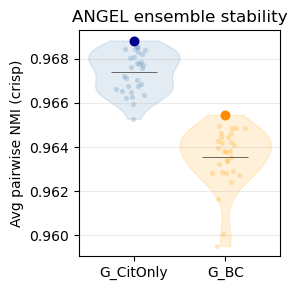

In [13]:
def plot_nmi_stability(stats_int, stats_comb):
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    fig, ax = plt.subplots(figsize=(3, 3))
    vp = ax.violinplot([nmi_int, nmi_comb], positions=[0, 1], widths=1,
                        showmeans=True, showmedians=False, showextrema=False)
    for body, color in zip(vp['bodies'], ['steelblue', 'orange']):
        body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.15)
    vp['cmeans'].set_color('#333333'); vp['cmeans'].set_linewidth(0.5)

    rng = np.random.default_rng(42)
    ax.scatter(rng.normal(0, 0.1, len(nmi_int)), nmi_int, s=14, color='steelblue', alpha=0.25, linewidths=0)
    ax.scatter(rng.normal(1, 0.1, len(nmi_comb)), nmi_comb, s=14, color='orange', alpha=0.25, linewidths=0)

    ax.scatter(0, nmi_int[stats_int['medoid_idx']], s=55, color='darkblue', edgecolors='white', linewidths=0.2, zorder=2)
    ax.scatter(1, nmi_comb[stats_comb['medoid_idx']], s=55, color='darkorange', edgecolors='white', linewidths=0.2, zorder=2)

    ax.set_xticks([0, 1]); ax.set_xticklabels(['G_CitOnly', 'G_BC'])
    ax.set_ylabel('Avg pairwise NMI (crisp)')
    ax.set_title('ANGEL ensemble stability')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout(); plt.show()

plot_nmi_stability(angel_internal_stats, angel_combined_stats)

### Size distribution

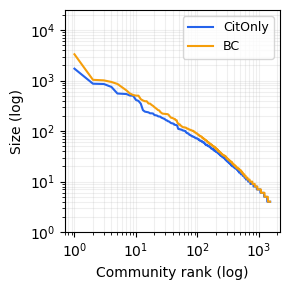

In [14]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           save_path=None):
    def _sizes(p):
        return np.array(sorted((len(c) for c in p.communities), reverse=True), dtype=float)

    sizes_a, sizes_b = _sizes(partition_a), _sizes(partition_b)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.plot(np.arange(1, len(sizes_a)+1), sizes_a, color=color_a, lw=1.5, label=label_a)
    ax.plot(np.arange(1, len(sizes_b)+1), sizes_b, color=color_b, lw=1.5, label=label_b)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1, 25000)
    ax.set_xlabel('Community rank (log)'); ax.set_ylabel('Size (log)')
    ax.grid(True, which='both', alpha=0.2); ax.legend(fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_size_distribution(
    angel_internal, 'CitOnly', angel_combined, 'BC',
    save_path=f'{OUTPUT_DIR}/angel_size_distribution.png'
)

## Bridge paper analysis

A paper in >=2 ANGEL communities is a bridge candidate.
Classify by neighbour dominance: >85% in one community = likely artefact, otherwise = true bridge.

In [15]:
def extract_overlapping_papers(angel_clustering):
    node_to_comms = angel_clustering.to_node_community_map()
    return dict(sorted(
        {n: sorted(c) for n, c in node_to_comms.items() if len(c) > 1}.items(),
        key=lambda x: len(x[1]), reverse=True
    ))

def analyze_bridge_topology(top_candidates, angel_clustering, G):
    comm_sets = [set(c) for c in angel_clustering.communities]
    rows = []
    for node_id, comm_ids in top_candidates:
        neighbours = set(G.neighbors(node_id))
        comm_neigh = {cid: len(neighbours & comm_sets[cid]) for cid in comm_ids}
        total_tracked = sum(comm_neigh.values())
        if total_tracked == 0:
            dominance, status = 100.0, 'Isolated'
        else:
            dominance = max(comm_neigh.values()) / total_tracked * 100
            status = 'Likely artefact (skewed)' if dominance > 85 else 'True bridge'

        node_data = G.nodes.get(node_id, {})
        fos = parse_labels(node_data.get('FOS'), level='sub')
        rows.append({
            'Node ID': node_id, 'Num Comms': len(comm_ids),
            'Total Degree': len(neighbours), 'Dominance %': round(dominance, 1),
            'Classification': status,
            'FOS': ', '.join(fos[:3]) if fos else 'N/A',
        })
    return pd.DataFrame(rows)

overlapping_int  = extract_overlapping_papers(angel_internal)
overlapping_comb = extract_overlapping_papers(angel_combined)
print(f"Bridge papers - G_CitOnly : {len(overlapping_int):,}")
print(f"Bridge papers - G_BC      : {len(overlapping_comb):,}")

top_bridges_comb = list(overlapping_comb.items())[:30]
df_bridges_comb = analyze_bridge_topology(top_bridges_comb, angel_combined, G_BC)
print('\n=== Top bridge papers - G_BC ===')
print(df_bridges_comb[['Node ID','Num Comms','Total Degree','Dominance %','Classification','FOS']].head(15).to_string())

Bridge papers - G_CitOnly : 2,947
Bridge papers - G_BC      : 4,374

=== Top bridge papers - G_BC ===
                                           Node ID  Num Comms  Total Degree  Dominance % Classification                                        FOS
0   doi_dedup___::0d0b363b440be69b0fc7219a7e31cf2a          6            39         40.9    True bridge                                        N/A
1   doi_dedup___::0e9f30c2a4aea682980531721bc23286          5            18         35.0    True bridge                   0106 biological sciences
2   doi_dedup___::55c5c0e747a5db2bc50792bb3ff252fa          5            59         50.0    True bridge  0301 basic medicine, 0303 health sciences
3   doi_dedup___::1c74aa6567653e27ea81ee0d3fbb9cfd          5            38         73.9    True bridge  0301 basic medicine, 0303 health sciences
4   doi_dedup___::077a4141fd7a8eb21676bd3eb97d1cc2          5            19         27.6    True bridge  0301 basic medicine, 0303 health sciences
5   doi_dedup___

## Fate analysis - BC impact in ANGEL (crisp projection)

Each community in `angel_crisp_internal` is classified by its mapping in `angel_crisp_combined`.
Crisp projection assigns each multi-member node to the community with most neighbours.

In [16]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}
        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue
        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)
    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'b_nodes': list(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [17]:
df_fates_angel, merge_events_angel, global_angel = classify_community_fates(
    part_a   = angel_crisp_internal,
    part_b   = angel_crisp_combined,
    G        = G_BC,
    name_a   = 'ANGEL_crisp/Internal',
    name_b   = 'ANGEL_crisp/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = FATE_MIN_SIZE,
)


  Fate Analysis: ANGEL_crisp/Internal -> ANGEL_crisp/Combined
  Communities analysed (>=20 nodes): 346
  NMI: 0.9518  |  VI: 0.4913
    dissolved       3  (  0.9%)  
    merged         72  ( 20.8%)  ##########
    partial         5  (  1.4%)  
    split           4  (  1.2%)  
    stable        262  ( 75.7%)  #####################################

  Merge events: 42  |  Cross-domain: 13


In [18]:
print_merge_report(merge_events_angel, top_n=10)


  TOP 10 MERGE EVENTS

  [1] [same-domain]  -  6 comms -> 1  (merged size: 2560)
       Merged FOS: 0103 physical sciences (93%) | 0302 clinical medicine (4%) | 0105 earth and related environmental sciences (1%)
         C1 (n= 1693): 0103 physical sciences (95%) | 0302 clinical medicine (3%)
         C2 (n=  439): 0103 physical sciences (95%) | 0301 basic medicine (2%)
         C3 (n=  112): 0103 physical sciences (82%) | 0302 clinical medicine (17%)
         C4 (n=  107): 0103 physical sciences (100%)
         C5 (n=   67): 0103 physical sciences (74%) | 0302 clinical medicine (26%)
         C6 (n=   30): 0103 physical sciences (80%) | 0302 clinical medicine (20%)

  [2] [cross-domain]  -  3 comms -> 1  (merged size: 859)
       Merged FOS: 0105 earth and related environmental sciences (78%) | 0106 biological sciences (6%) | 0601 history and archaeology (6%)
         C1 (n=  819): 0105 earth and related environmental sciences (79%) | 0601 history and archaeology (5%)
         C2 (n=

## Semantic purity

In [19]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    def _gini_inequality(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini_inequality(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini_inequality': (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini_inequality'] - p_int['gini_inequality']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini ineq.: {p_int['gini_inequality']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini ineq.: {p_comb['gini_inequality']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Delta: Entropy {de:+.4f} ({e_verdict}) | Gini ineq. {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(angel_internal, angel_combined, G_CitOnly_undir, G_BC)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.3785 | Gini ineq.: 0.3688 | Comms: 723
  Combined  | Entropy: 0.3750 | Gini ineq.: 0.4273 | Comms: 780
  Delta: Entropy -0.0034 (SAME) | Gini ineq. +0.0585 (BETTER)

FOS:
  Internal  | Entropy: 0.5499 | Gini ineq.: 0.5214 | Comms: 723
  Combined  | Entropy: 0.5383 | Gini ineq.: 0.5714 | Comms: 780
  Delta: Entropy -0.0117 (BETTER) | Gini ineq. +0.0501 (BETTER)

SDG:
  Internal  | Entropy: 0.6135 | Gini ineq.: 0.5482 | Comms: 706
  Combined  | Entropy: 0.6025 | Gini ineq.: 0.5721 | Comms: 765
  Delta: Entropy -0.0110 (BETTER) | Gini ineq. +0.0239 (BETTER)


## Gini permutation test - merge significance

Same corpus-level null model as Leiden and InfoMap notebooks.

In [20]:
def gini_concentration(labels):
    labels = np.asarray(labels)
    labels = labels[labels != '']
    if len(labels) == 0:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)

def build_corpus_fos_pool(G, attr='FOS', level='sub'):
    pattern = re.compile(r'^\d{4}\s') if level == 'sub' else re.compile(r'^\d{2}\s')
    all_labels = []
    for _, data in G.nodes(data=True):
        val = data.get(attr)
        if not val:
            continue
        parts = [p.strip() for p in str(val).split(';') if p.strip()]
        all_labels.extend(p for p in parts if pattern.match(p))
    return np.array(all_labels)

def gini_permutation_test(merge_labels, corpus_pool, n_permutations=1000, seed=42):
    rng = np.random.default_rng(seed)
    merge_labels = np.asarray(merge_labels)
    clean_labels = merge_labels[merge_labels != '']
    if len(clean_labels) == 0:
        return {'observed_gini': np.nan, 'p_value': np.nan, 'significant': False}
    n_draw = len(clean_labels)
    observed = gini_concentration(clean_labels)
    null_ginis = np.empty(n_permutations)
    for i in range(n_permutations):
        sample = rng.choice(corpus_pool, size=n_draw, replace=True)
        null_ginis[i] = gini_concentration(sample)
    p_value = np.mean(null_ginis <= observed)
    return {
        'observed_gini': float(observed),
        'null_mean': float(null_ginis.mean()),
        'null_std': float(null_ginis.std()),
        'null_p5': float(np.percentile(null_ginis, 5)),
        'null_p95': float(np.percentile(null_ginis, 95)),
        'p_value': float(p_value),
        'significant': p_value < 0.05
    }

def validate_merges(merges, fos_labels_dict, corpus_pool,
                    n_permutations=1000, cache_dir=OUTPUT_DIR, force=False):
    cache_file = cache_dir / f"angel_gini_validation_{len(merges)}merges.pkl"
    if not force and cache_file.exists():
        results = _cache_load(cache_file)
        for r in results:
            sig = "SIG" if r['significant'] else "n.s."
            print(f"  {r['merge_name']:6s} | n={r['n_nodes']:5d} | "
                  f"Gini={r['observed_gini']:.3f} vs {r['null_mean']:.3f} | "
                  f"p={r['p_value']:.4f} | {sig}")
        return results
    results = []
    for merge in merges:
        labels = np.array([fos_labels_dict.get(nid, '') for nid in merge['node_ids']])
        test = gini_permutation_test(labels, corpus_pool, n_permutations=n_permutations)
        test['merge_name'] = merge['name']
        test['n_nodes'] = len(merge['node_ids'])
        test['n_labelled'] = int(np.sum(labels != ''))
        results.append(test)
        sig = "SIG" if test['significant'] else "n.s."
        print(f"  {merge['name']:6s} | n={test['n_nodes']:5d} | "
              f"Gini={test['observed_gini']:.3f} vs {test['null_mean']:.3f} | "
              f"p={test['p_value']:.4f} | {sig}")
    _cache_save(cache_file, results)
    return results

In [21]:
corpus_pool = build_corpus_fos_pool(G_BC, attr='FOS', level='sub')
print(f"Corpus FOS pool: {len(corpus_pool)} labels, {len(np.unique(corpus_pool))} unique")

fos_labels_dict = {}
for nid, data in G_BC.nodes(data=True):
    fos = data.get('FOS', '')
    parts = [p.strip() for p in str(fos).split(';') if re.match(r'^\d{4}\s', p.strip())]
    fos_labels_dict[nid] = parts[0] if parts else ''

merges = [{'name': f"M{i+1}", 'node_ids': evt['b_nodes']}
          for i, evt in enumerate(merge_events_angel)]

print(f"\nTesting {len(merges)} merge events:")
gini_results = validate_merges(merges, fos_labels_dict, corpus_pool)

sig_count = sum(1 for r in gini_results if r['significant'])
print(f"\n{sig_count}/{len(gini_results)} merges significant (p < 0.05)")

Corpus FOS pool: 63248 labels, 39 unique

Testing 42 merge events:
  M1     | n= 2560 | Gini=0.107 vs 0.893 | p=0.0000 | SIG
  M2     | n=  859 | Gini=0.387 vs 0.892 | p=0.0000 | SIG
  M3     | n=  852 | Gini=0.664 vs 0.892 | p=0.0000 | SIG
  M4     | n=  714 | Gini=0.381 vs 0.892 | p=0.0000 | SIG
  M5     | n=  629 | Gini=0.033 vs 0.892 | p=0.0000 | SIG
  M6     | n=  459 | Gini=0.384 vs 0.891 | p=0.0000 | SIG
  M7     | n=  441 | Gini=0.339 vs 0.891 | p=0.0000 | SIG
  M8     | n=  342 | Gini=0.382 vs 0.890 | p=0.0000 | SIG
  M9     | n=  339 | Gini=0.248 vs 0.890 | p=0.0000 | SIG
  M10    | n=  326 | Gini=0.119 vs 0.890 | p=0.0000 | SIG
  M11    | n=  265 | Gini=0.569 vs 0.889 | p=0.0000 | SIG
  M12    | n=  244 | Gini=0.498 vs 0.889 | p=0.0000 | SIG
  M13    | n=  215 | Gini=0.635 vs 0.888 | p=0.0000 | SIG
  M14    | n=  203 | Gini=0.523 vs 0.889 | p=0.0000 | SIG
  M15    | n=  193 | Gini=0.359 vs 0.888 | p=0.0000 | SIG
  M16    | n=  192 | Gini=0.067 vs 0.888 | p=0.0000 | SIG
  M17

### Summary - ANGEL (single-algorithm view)

ANGEL provides the overlap-centric perspective required to analyze BC effects at community boundaries
and to identify potential bridge nodes.

Main takeaways:
- ensemble medoid selection (30 runs, NMI on crisp projections) ensures partition robustness;
- BC-driven increase in overlap rate quantifies boundary expansion;
- bridge paper topology (true bridge vs artefact) separates structural signal from noise;
- Gini permutation test validates that merges reflect genuine disciplinary concentration;
- semantic purity diagnostics (entropy, Gini inequality) confirm thematic coherence.

Phase conclusion: ANGEL complements Leiden and InfoMap by making boundary structure explicit,
enabling direct identification of papers that span multiple intellectual communities.